# Technical Architecture & Data Engineering Pipeline

## 1. Infrastructure Strategy
Standard business intelligence tools (like Power BI or Excel) face severe memory constraints and UI rendering latency when directly ingesting datasets exceeding 20 million rows. Attempting to run Exploratory Data Analysis (EDA) on the raw Parquet file using Pandas would result in out-of-memory crashes.

To bypass these limitations, this project utilized a two-tiered architectural approach:
1. **Exploratory Phase (Pandas + DuckDB):** Extracted a lightweight 5% random sample (approx. 1.01 million rows) using DuckDB to prototype cleaning logic and statistical thresholds in Pandas.
2. **Production Phase (DuckDB SQL):** Executed a custom, in-memory pipeline using DuckDB to clean and pre-aggregate the entire 22-million row dataset down to a 366,000-row semantic model in roughly 11 seconds.

## 2. Exploratory Data Analysis & Rule Definition
The raw TLC High Volume For-Hire Vehicle dataset contains significant physical and financial anomalies. Below is the exploratory logic used to define the programmatic cleaning rules based on statistical realities rather than hardcoded assumptions.

### Step 2.1: Extracting a Lightweight Sample
Instead of loading 22 million rows into RAM, we use DuckDB to instantly pull a random 5% sample.

In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Extract 5% sample for safe EDA
source_path = r'C:\Users\Rango\Downloads\fhvhv_tripdata_2026-03.parquet' # path to the local parquet file
sample_query = f"""
    SELECT * 
    FROM '{source_path}'
    USING SAMPLE 5%
"""
sample_df = duckdb.sql(sample_query).df()
print(f"Sample successfully loaded: {len(sample_df)} rows")

Sample successfully loaded: 1110016 rows


### Step 2.2: Chronological and Physical Anomalies
We tested baseline rules to eliminate physical impossibilities and GPS distortion:
1. Request time must precede scene arrival, pickup, and drop-off.
2. Trips with zero miles or negative fares are dropped.
3. The 50 MPH Proxy: Average speed exceeding 50 mph across an entire trip within the NYC grid indicates GPS distortion.

In [2]:
# 1. Checking Negative Fares
negative_fares = sample_df[sample_df['base_passenger_fare'] < 0]
print(f"Rows with negative fares: {len(negative_fares)}")

# 2. Checking Zero Mileage (Teleports)
suspicious_trips = sample_df[sample_df['trip_miles'] <= 0]
print(f"Rows with zero mileage: {len(suspicious_trips)}")

# 3. Checking Impossible City Speeds (>50 mph proxy)
sample_df['avg_speed'] = sample_df['trip_miles'] / (sample_df['trip_time'] / 3600)
impossible_speed = sample_df[sample_df['avg_speed'] > 50]
print(f"Rows with abnormal speeds (>50mph proxy): {len(impossible_speed)}")

Rows with negative fares: 307
Rows with zero mileage: 147
Rows with abnormal speeds (>50mph proxy): 367


### Step 2.3: The "Inverted Pay" Elbow Method
A significant anomaly was discovered where drivers earned more than the passenger paid (`driver_pay > base_passenger_fare`). Initial counts showed this applied to a massive portion of the sample, indicating platform bonuses rather than strict data errors. 

To determine the anomalous threshold, we calculate a `pay_ratio` and test multiple thresholds. Plotting this reveals a sharp drop-off and flattening immediately after the 1.5x mark, which becomes our trim rule.

In [ ]:
sample_df['pay_ratio'] = sample_df['driver_pay'] / sample_df['base_passenger_fare'].replace(0, float('nan'))

print(f"Trips where driver earns more than base fare: {len(sample_df[sample_df['pay_ratio'] > 1])}")
print(f"Trips where driver earns 1.25x+ more than base fare: {len(sample_df[sample_df['pay_ratio'] > 1.25])}")
print(f"Trips where driver earns 1.5x+ the base fare: {len(sample_df[sample_df['pay_ratio'] > 1.5])}")
print(f"Trips where driver earns 1.75x+ more than base fare: {len(sample_df[sample_df['pay_ratio'] > 1.75])}")
print(f"Trips where driver earns 2x+ the base fare: {len(sample_df[sample_df['pay_ratio'] > 2])}")

Trips where driver earns more than base fare: 161002
Trips where driver earns 1.25x+ more than base fare: 45914
Trips where driver earns 1.5x+ the base fare: 15088
Trips where driver earns 1.75x+ more than base fare: 5226
Trips where driver earns 2x+ the base fare: 2222


### Step 2.4: Distribution Skew & The "Hidden Ingredients"
Visualizing the distribution of base fares versus trip miles reveals a heavy right-skew. 
The mileage distribution drops off significantly faster than the base fare distribution. Distance alone is a poor predictor of fare cost, as "hidden ingredients" (tolls, time delays, and surge multipliers) heavily pad the fares. 

Because of this skew, using a mean average or hardcoded caps to trim outliers compromises the data. Instead, the production pipeline will use DuckDB's `quantile_cont` to dynamically trim the 99th percentile.

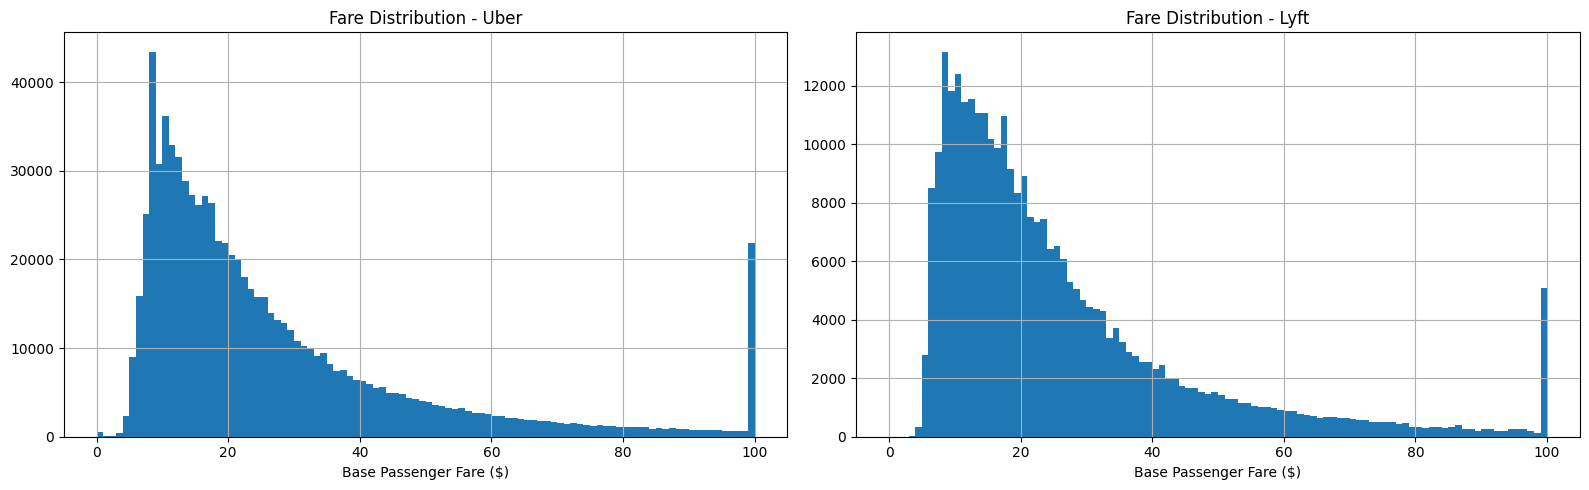

In [4]:
fig, (uber, lyft) = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

# Uber Fare Distribution
uber_df = sample_df[sample_df['hvfhs_license_num'] == 'HV0003']
uber_df_fares = uber_df['base_passenger_fare'].clip(lower=0, upper=100) 
uber_df_fares.hist(bins=100, ax=uber, alpha=1)
uber.set_title('Fare Distribution - Uber')
uber.set_xlabel('Base Passenger Fare ($)')

# Lyft Fare Distribution
lyft_df = sample_df[sample_df['hvfhs_license_num'] == 'HV0005']
lyft_df_fares = lyft_df['base_passenger_fare'].clip(lower=0, upper=100)
lyft_df_fares.hist(bins=100, ax=lyft, alpha=1)
lyft.set_title('Fare Distribution - Lyft')
lyft.set_xlabel('Base Passenger Fare ($)')

plt.tight_layout()
plt.show()

## 3. The Production Pipeline
The final deployment script below abandons Pandas (to avoid memory crashes) and applies all the rules discovered above strictly in-memory using DuckDB SQL. 

Because airport runs (JFK/LaGuardia) inherently distort time and distance metrics, the 99th percentile thresholds are calculated and applied independently for 'Airport' trips (where `airport_fee > 0`) and standard 'City' trips. The cleaned data is then instantly aggregated along dimensional axes (Date, Hour, Zone, Company) to feed the Power BI semantic model.

In [ ]:
import duckdb
import time

# Raw TLC HVFHV dataset (22 Million Rows)
raw_file_path = r'C:\Users\Rango\Downloads\fhvhv_tripdata_2026-03.parquet' 
output_file_master = r'C:\Users\Rango\Downloads\Master_Dashboard.csv'

print("Processing 22 million rows in-memory via DuckDB...")
start_time = time.time()

unified_pipeline_query = f"""
COPY (
    -- STEP 1: Calculate Segmented Outlier Thresholds
    WITH Thresholds AS (
        SELECT 
            CASE WHEN airport_fee > 0 THEN 'Airport' ELSE 'City' END AS trip_segment,
            quantile_cont(base_passenger_fare, 0.99) AS p99_fare,
            quantile_cont(trip_miles, 0.99) AS p99_miles,
            quantile_cont(trip_time, 0.99) AS p99_time,
            quantile_cont(driver_pay, 0.99) AS p99_driver_pay
        FROM '{raw_file_path}'
        GROUP BY CASE WHEN airport_fee > 0 THEN 'Airport' ELSE 'City' END
    ),
    
    -- STEP 2: Apply Physical/Logical Constraints
    CleanedBase AS (
        SELECT *,
               CASE WHEN airport_fee > 0 THEN 'Airport' ELSE 'City' END AS trip_segment
        FROM '{raw_file_path}'
        WHERE request_datetime <= on_scene_datetime            
          AND on_scene_datetime <= pickup_datetime             
          AND pickup_datetime < dropoff_datetime               
          AND base_passenger_fare > 0                          
          AND trip_miles > 0                                   
          AND trip_time > 60 AND trip_time < 14400             
          AND (trip_miles / (trip_time / 3600.0)) <= 50        
          AND (driver_pay / base_passenger_fare) <= 1.5        
    ),
    
    -- STEP 3: Trim Top 1% Outliers
    FullyCleaned AS (
        SELECT c.* EXCLUDE (trip_segment)
        FROM CleanedBase c
        JOIN Thresholds t 
          ON c.trip_segment = t.trip_segment
        WHERE c.base_passenger_fare <= t.p99_fare
          AND c.trip_miles <= t.p99_miles
          AND c.trip_time <= t.p99_time
          AND c.driver_pay <= t.p99_driver_pay
    )
    
    -- STEP 4: This is now the ONLY select inside the COPY
    SELECT 
        CAST(request_datetime AS DATE) AS request_date,
        DAYNAME(request_datetime) AS day_of_week,
        CASE WHEN DAYNAME(request_datetime) IN ('Saturday', 'Sunday') THEN 'Weekend' 
        ELSE 'Weekday' END AS day_type,
        HOUR(request_datetime) AS hour_of_day,
        PULocationID,
        CASE WHEN hvfhs_license_num = 'HV0003' THEN 'Uber' 
             WHEN hvfhs_license_num = 'HV0005' THEN 'Lyft' 
             ELSE hvfhs_license_num END AS company,
        
        COUNT(*) AS trip_volume,
        AVG(date_diff('minute', request_datetime, on_scene_datetime)) AS avg_driver_travel_time,
        AVG(date_diff('minute', on_scene_datetime, pickup_datetime)) AS avg_passenger_boarding_time,
        AVG(date_diff('minute', request_datetime, pickup_datetime)) AS avg_total_wait_time,
        SUM(CASE WHEN shared_request_flag = 'Y' THEN 1 ELSE 0 END) AS total_shared_requests,
        SUM(CASE WHEN shared_match_flag = 'Y' THEN 1 ELSE 0 END) AS total_shared_matches,
        
        SUM(base_passenger_fare) AS total_revenue,
        AVG(tips) AS avg_tip_amount,
        SUM(tips) AS total_tips,
        SUM(base_passenger_fare) / NULLIF(SUM(trip_miles), 0) AS revenue_per_mile,
        SUM(driver_pay) / NULLIF((SUM(trip_time) / 3600.0), 0) AS driver_hourly_earnings
        
    FROM FullyCleaned
    WHERE PULocationID IS NOT NULL
      AND PULocationID NOT IN (1, 264, 265) 
    GROUP BY ALL -- 'GROUP BY ALL' is a clean DuckDB shortcut
) TO '{output_file_master}' (HEADER, DELIMITER ',');
"""

duckdb.sql(unified_pipeline_query)
end_time = time.time()
print(f"Pipeline executed successfully in {round(end_time - start_time, 2)} seconds.")

Processing 22 million rows in-memory via DuckDB...
Pipeline executed successfully in 11.14 seconds.


In [18]:
Master_dashboard = pd.read_csv(r'C:\Users\Rango\Downloads\Master_Dashboard.csv')
print(f"The Master Dashboard has {Master_dashboard.shape[0]} rows and {Master_dashboard.shape[1]} columns.")

The Master Dashboard has 366666 rows and 18 columns.
